# Bicing Barcelona — Clustering d'estacions per comportament operatiu

**Dades:** Open Data Barcelona · Taula `features_clustering` · 548 estacions · 2022–2024

Aquest notebook agrupa les estacions Bicing en clusters segons el seu comportament operatiu (disponibilitat, variabilitat, saturació), per identificar perfils d'ús diferenciats:

1. **Càrrega i inspecció** — connexió a DuckDB i anàlisi de valors mancants
2. **Preparació** — filtratge d'estacions i normalització de features
3. **Selecció de k** — mètode Elbow i Silhouette Score
4. **Clustering KMeans** — agrupació amb k=5 i interpretació dels perfils
5. **Visualització** — perfils NAB, heatmap de centroides, distribució per districte i mapa interactiu
6. **Exportació** — CSV i taula DuckDB amb els resultats

Cada secció genera els gràfics (PNG) i dades (CSV). Tots els fitxers de sortida es guarden en subcarpetes: `png/`, `csv/`, `html/`.

---
## 0. Configuració

Importem les biblioteques, connectem a la base de dades DuckDB i definim els paràmetres globals que s'utilitzen al llarg de tot el notebook.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from branca.element import Element
import os
import glob
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Estil global de Matplotlib ───────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'figure.dpi':       150,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
    'axes.spines.top':  False,
    'axes.spines.right': False,
})

# ── Colors per als clusters ──────────────────────────────────────────────────
COLORS_CLUSTER = ['#E53935', '#FDD835', '#1E88E5', '#43A047', '#8E24AA']  # Parchís: vermell, groc, blau, verd + lila

# ── Carpetes de sortida ──────────────────────────────────────────────────────
for carpeta in ['png', 'csv', 'html']:
    os.makedirs(carpeta, exist_ok=True)

# ── Connexió a DuckDB ────────────────────────────────────────────────────────
DB_PATH = 'bicicletes.duckdb'
con = duckdb.connect(DB_PATH)
print('Connexió establerta a', DB_PATH)

Connexió establerta a bicicletes.duckdb


---
## 1. Càrrega i inspecció de les dades

Carreguem la taula `features_clustering`, que conté 32 columnes amb mètriques operatives per a cadascuna de les 548 estacions (2022–2024).

In [2]:
# ── Càrrega de la taula de features ──────────────────────────────────────────
df = con.execute("SELECT * FROM features_clustering").df()

print(f"Dimensions: {df.shape[0]} estacions × {df.shape[1]} columnes")
display(df.head(3))

Dimensions: 548 estacions × 32 columnes


,id_estacio,lat,lon,nom_districte,capacitat_mitja,nab_lab_h06_08,nab_lab_h08_10,nab_lab_h10_12,nab_lab_h12_14,nab_lab_h14_16,...,std_nab_punta_tarda,mitja_rang_bicis_norm,mitja_rang_anclatges_norm,ratio_buida_global,ratio_plena_global,ratio_extremes_global,ratio_buida_hora_punta,ratio_plena_hora_punta,nab_mitja_punta_matinada,nab_mitja_punta_tarda
0,1,41.3979779,2.1801069,Eixample,43.984517,0.446706,0.194032,0.134690,0.158342,0.231182,...,0.174353,0.057390,0.057668,0.069286,0.001597,0.0,0.119991,0.000107,0.261728,0.277993
1,10,41.3467746,2.1436235,Sants-Montjuïc,42.690750,0.364226,0.498261,0.554787,0.546882,0.487326,...,0.186026,0.006789,0.006635,0.004942,0.002186,0.0,0.003730,0.003410,0.458229,0.384064
2,100,41.379363,2.143868,Sants-Montjuïc,20.296646,0.397330,0.331381,0.336961,0.321394,0.328801,...,0.244753,0.097724,0.097923,0.195332,0.023533,0.0,0.157076,0.021100,0.379899,0.304220


---
## 2. Anàlisi de valors mancants (NaN)

Abans de fer el clustering, cal entendre per què algunes estacions tenen dades incompletes i no poden participar en l'anàlisi.

In [3]:
# ── Identifiquem les columnes numèriques (features) ──────────────────────────
# Excloem id_estacio, lat, lon que són identificadors/coordenades
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id_estacio', 'lat', 'lon']]

print(f"Columnes numèriques (features): {len(numeric_cols)}")
print()

# ── Distribució de NaN per estació ───────────────────────────────────────────
nan_per_row = df[numeric_cols].isnull().sum(axis=1)

print("Distribució de NaN per estació:")
print("(quantes estacions tenen 0, 1, 2... valors NaN)")
print()
dist = nan_per_row.value_counts().sort_index()
for n_nan, count in dist.items():
    print(f"  {int(n_nan):2d} NaN → {count} estacions")
print(f"\nTotal estacions: {len(df)}")

Columnes numèriques (features): 28

Distribució de NaN per estació:
(quantes estacions tenen 0, 1, 2... valors NaN)

   0 NaN → 516 estacions
   9 NaN → 1 estacions
  11 NaN → 1 estacions
  23 NaN → 30 estacions

Total estacions: 548


In [4]:
# ── Columnes amb valors NaN ───────────────────────────────────────────────────
nan_per_col = df[numeric_cols].isnull().sum()
cols_with_nan = nan_per_col[nan_per_col > 0].sort_values(ascending=False)

if len(cols_with_nan) > 0:
    print("Columnes amb valors NaN:")
    print()
    for col, count in cols_with_nan.items():
        print(f"  {col}: {count} estacions sense dada")
else:
    print("Cap columna amb NaN")

Columnes amb valors NaN:

  nab_lab_h06_08: 32 estacions sense dada
  nab_lab_h08_10: 32 estacions sense dada
  nab_fest_h22_00: 32 estacions sense dada
  nab_fest_h06_10: 32 estacions sense dada
  nab_lab_h22_00: 32 estacions sense dada
  nab_lab_h20_22: 32 estacions sense dada
  nab_lab_h18_20: 32 estacions sense dada
  nab_mitja_punta_matinada: 32 estacions sense dada
  std_nab_punta_matinada: 32 estacions sense dada
  std_nab_punta_tarda: 31 estacions sense dada
  nab_fest_h18_22: 31 estacions sense dada
  capacitat_mitja: 30 estacions sense dada
  nab_lab_h14_16: 30 estacions sense dada
  nab_lab_h12_14: 30 estacions sense dada
  nab_lab_h10_12: 30 estacions sense dada
  nab_lab_h16_18: 30 estacions sense dada
  nab_fest_h14_18: 30 estacions sense dada
  nab_fest_h10_14: 30 estacions sense dada
  mitja_nab_global: 30 estacions sense dada
  std_nab_global: 30 estacions sense dada
  mitja_rang_bicis_norm: 30 estacions sense dada
  mitja_rang_anclatges_norm: 30 estacions sense dada
 

In [5]:
# ── Criteri d'eliminació ──────────────────────────────────────────────────────
# KMeans necessita un valor numèric a CADA feature per calcular distàncies.
# Si una estació té la majoria de features buides, no tenim informació
# suficient per assignar-la a cap cluster.
#
# Criteri: eliminem estacions amb més de 10 NaN (de 28 features).
# Això correspon a estacions noves, sense prou historial 2022-2024.

estacions_invalides = df[nan_per_row > 10][['id_estacio', 'nom_districte']].copy()
estacions_invalides['n_nan'] = nan_per_row[nan_per_row > 10].values

print(f"Estacions eliminades (>10 NaN de 28 features): {len(estacions_invalides)}")
print(f"Estacions vàlides per al clustering: {len(df) - len(estacions_invalides)}")
print()
print("Detall de les estacions eliminades:")
display(estacions_invalides.sort_values('n_nan', ascending=False))

Estacions eliminades (>10 NaN de 28 features): 31
Estacions vàlides per al clustering: 517

Detall de les estacions eliminades:


,id_estacio,nom_districte,n_nan
471,547,Eixample,23
473,553,Gràcia,23
474,554,Sarrià-Sant Gervasi,23
477,561,Les Corts,23
475,558,Horta-Guinardó,23
478,563,Les Corts,23
479,564,Sants-Montjuïc,23
483,568,Sarrià-Sant Gervasi,23
480,565,Sant Andreu,23
481,566,Sant Martí,23


---
## 3. Filtratge i preparació de les dades

Eliminem les estacions amb massa NaN i imputem els pocs NaN restants amb la mediana.

In [6]:
# ── Filtrar estacions invàlides ───────────────────────────────────────────────
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df_valid = df[nan_per_row <= 10].copy()
df_valid['lat'] = pd.to_numeric(df_valid['lat'], errors='coerce')
df_valid['lon'] = pd.to_numeric(df_valid['lon'], errors='coerce')

# ── Imputar NaN restants amb la mediana ──────────────────────────────────────
for col in numeric_cols:
    if df_valid[col].isnull().any():
        df_valid[col] = df_valid[col].fillna(df_valid[col].median())

print(f"Estacions per al clustering: {len(df_valid)}")
print(f"NaN restants: {df_valid[numeric_cols].isnull().sum().sum()}")

Estacions per al clustering: 517
NaN restants: 0


---
## 4. Normalització de les features

Apliquem `StandardScaler` (z-score) perquè totes les features tinguin el mateix pes en el càlcul de distàncies. Sense normalitzar, les features amb valors grans (com la capacitat) dominarien el clustering.

In [7]:
# ── Normalització z-score ─────────────────────────────────────────────────────
feature_cols = numeric_cols  # 28 features

X = df_valid[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features normalitzades: {len(feature_cols)}")
for i, f in enumerate(feature_cols):
    print(f"  {i+1:2d}. {f}")

Features normalitzades: 28
   1. capacitat_mitja
   2. nab_lab_h06_08
   3. nab_lab_h08_10
   4. nab_lab_h10_12
   5. nab_lab_h12_14
   6. nab_lab_h14_16
   7. nab_lab_h16_18
   8. nab_lab_h18_20
   9. nab_lab_h20_22
  10. nab_lab_h22_00
  11. nab_fest_h06_10
  12. nab_fest_h10_14
  13. nab_fest_h14_18
  14. nab_fest_h18_22
  15. nab_fest_h22_00
  16. std_nab_global
  17. mitja_nab_global
  18. std_nab_punta_matinada
  19. std_nab_punta_tarda
  20. mitja_rang_bicis_norm
  21. mitja_rang_anclatges_norm
  22. ratio_buida_global
  23. ratio_plena_global
  24. ratio_extremes_global
  25. ratio_buida_hora_punta
  26. ratio_plena_hora_punta
  27. nab_mitja_punta_matinada
  28. nab_mitja_punta_tarda


---
## 5. Selecció del nombre de clusters

Provem k de 2 a 12 i observem dues mètriques:
- **Inèrcia (Elbow):** suma de distàncies dins dels clusters. Busquem el "colze" on la millora es redueix.
- **Silhouette:** mesura de la qualitat de la separació entre clusters (més alt = millor).


In [8]:
# ── Mètriques per a k = 2..12 ────────────────────────────────────────────────
k_range = range(2, 13)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette': silhouettes,
})
print(metrics_df.to_string(index=False))

 k     inertia  silhouette
 2 9103.772386    0.322658
 3 7574.980338    0.239274
 4 6860.617863    0.240275
 5 6216.208328    0.230379
 6 5768.157074    0.192059
 7 5299.299184    0.195590
 8 4887.870096    0.206938
 9 4503.756460    0.217626
10 4317.780840    0.220839
11 4141.646735    0.200920
12 3964.981935    0.194393


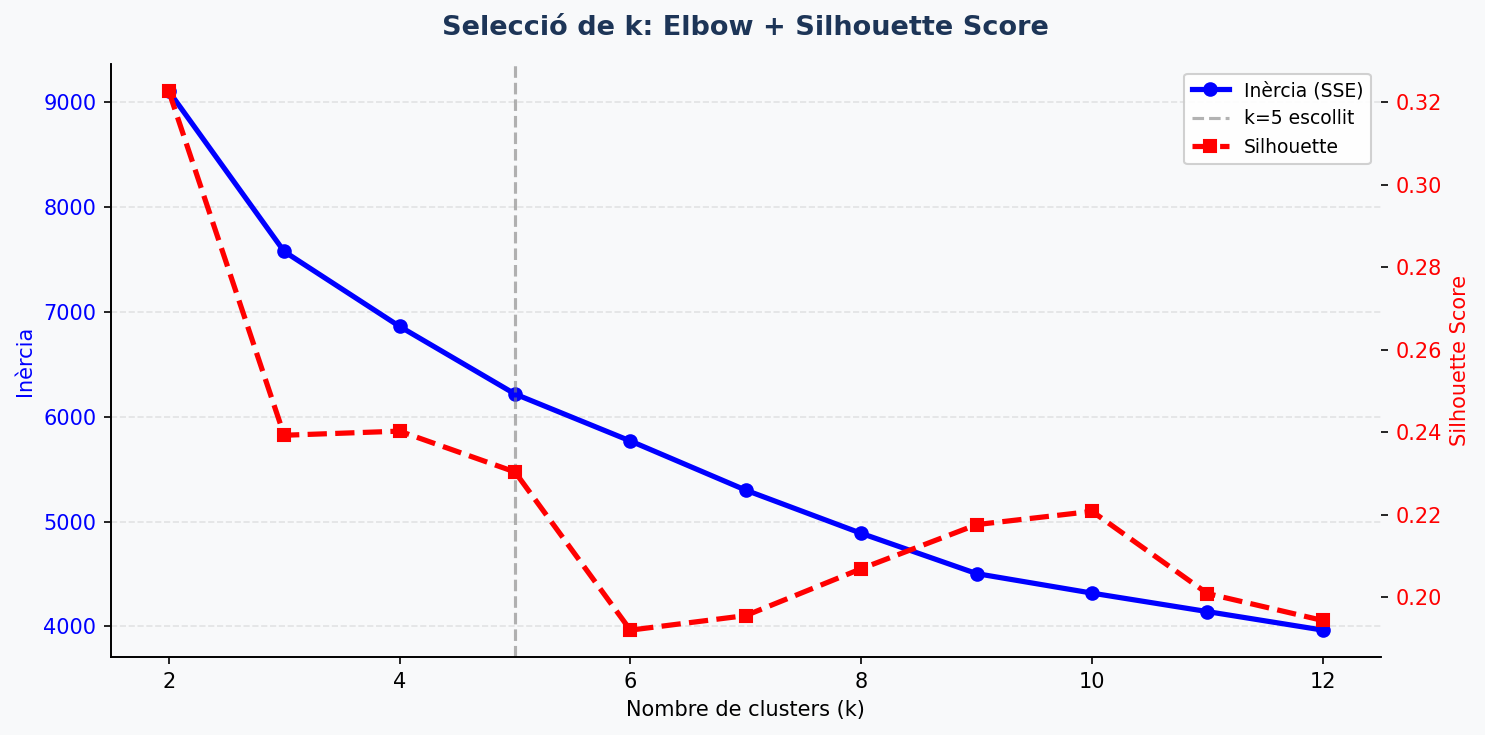

Guardat: png/elbow_silhouette.png
Guardat: csv/cluster_metrics.csv


In [9]:
# ── Gràfic Elbow + Silhouette ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F8F9FA'); ax1.set_facecolor('#F8F9FA')
k_list = list(k_range)

ax1.plot(k_list, inertias, 'b-o', linewidth=2.5, label='Inèrcia (SSE)')
ax1.set_xlabel('Nombre de clusters (k)', fontsize=10)
ax1.set_ylabel('Inèrcia', color='b', fontsize=10)
ax1.tick_params(axis='y', labelcolor='b')
ax1.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='k=5 escollit')

ax2 = ax1.twinx()
ax2.plot(k_list, silhouettes, 'r--s', linewidth=2.5, label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='r', fontsize=10)
ax2.tick_params(axis='y', labelcolor='r')

# Llegenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9, framealpha=.9)

ax1.set_title('Selecció de k: Elbow + Silhouette Score',
              fontsize=13, fontweight='bold', pad=14, color='#1D3557')
ax1.grid(axis='y', ls='--', alpha=.3)

plt.tight_layout()
plt.savefig('png/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardat: png/elbow_silhouette.png')

metrics_df.to_csv('csv/cluster_metrics.csv', index=False)
print('Guardat: csv/cluster_metrics.csv')

---
## 6. Clustering KMeans amb k=5

Escollim k=5 perquè ofereix un bon equilibri entre inèrcia, silhouette i interpretabilitat dels resultats.

In [10]:
# ── KMeans final amb k=5 ─────────────────────────────────────────────────────
K_FINAL = 5

km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
labels = km.fit_predict(X_scaled)
df_valid['cluster'] = labels

print("Estacions per cluster:")
print(df_valid['cluster'].value_counts().sort_index())
print(f"\nSilhouette (k={K_FINAL}): {silhouette_score(X_scaled, labels):.4f}")

Estacions per cluster:
cluster
0    132
1     42
2    162
3    122
4     59
Name: count, dtype: int64

Silhouette (k=5): 0.2304


---
## 7. Interpretació i noms dels clusters

Analitzem els centroides (valors mitjans de cada cluster en escala original) per assignar noms descriptius.


In [11]:
# ── Centroides en escala original ─────────────────────────────────────────────
centroids_scaled = km.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_orig, columns=feature_cols)
centroids_df['cluster'] = range(K_FINAL)

# Features clau per interpretar
key_cols = ['capacitat_mitja', 'mitja_nab_global', 'std_nab_global',
            'ratio_buida_global', 'ratio_plena_global',
            'ratio_buida_hora_punta', 'nab_mitja_punta_matinada', 'nab_mitja_punta_tarda']

print("Centroides — features clau:")
display(centroids_df[['cluster'] + key_cols].round(3))

Centroides — features clau:


,cluster,capacitat_mitja,mitja_nab_global,std_nab_global,ratio_buida_global,ratio_plena_global,ratio_buida_hora_punta,nab_mitja_punta_matinada,nab_mitja_punta_tarda
0,0,25.161,0.217,0.201,0.206,0.004,0.281,0.224,0.166
1,1,20.819,0.587,0.285,0.039,0.137,0.038,0.554,0.617
2,2,24.611,0.370,0.265,0.123,0.024,0.188,0.287,0.323
3,3,30.630,0.490,0.253,0.023,0.037,0.031,0.465,0.479
4,4,26.342,0.359,0.294,0.156,0.054,0.152,0.533,0.280


In [12]:
# ── Noms descriptius basats en el comportament observat ────────────────────────
cluster_names = {
    0: "Perifèric Baix Ús",
    1: "Central Alta Ocupació",
    2: "Origen Commuter Matí",
    3: "Ús Mixt Equilibrat",
    4: "Residencial Entrada Tarda"
}

df_valid['cluster_name'] = df_valid['cluster'].map(cluster_names)
centroids_df['cluster_name'] = centroids_df['cluster'].map(cluster_names)
centroids_df['n_stations'] = [
    (df_valid['cluster'] == c).sum() for c in range(K_FINAL)
]

print("Resum per cluster:")
print(df_valid.groupby('cluster_name').size().reset_index(name='n_estacions'))

Resum per cluster:
                cluster_name  n_estacions
0      Central Alta Ocupació           42
1       Origen Commuter Matí          162
2          Perifèric Baix Ús          132
3  Residencial Entrada Tarda           59
4         Ús Mixt Equilibrat          122


---
## 8. Perfils NAB per cluster

Visualització del nivell mitjà de bicicletes disponibles (NAB) al llarg del dia, per dies laborables i festius. Això ens ajuda a entendre com cada cluster consumeix i rep bicicletes.


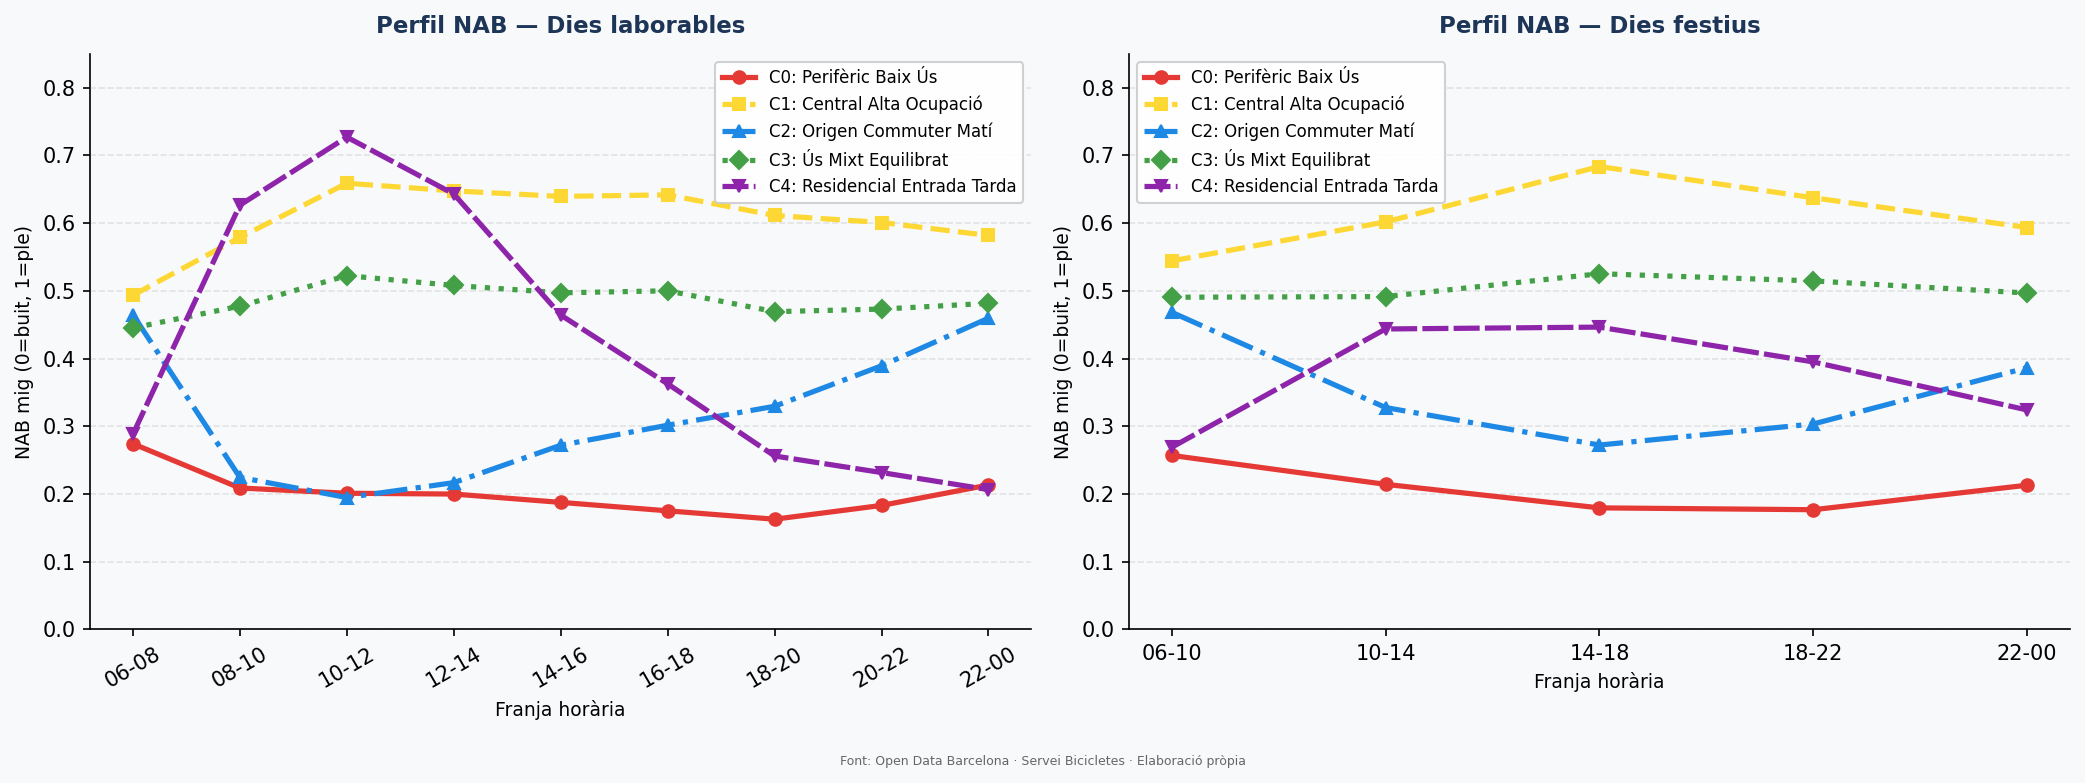

Guardat: png/nab_profiles.png


In [13]:
# ── Perfils NAB per cluster: laborables vs. festius ───────────────────────────
lab_slots = ['06-08', '08-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-22', '22-00']
lab_cols = ['nab_lab_h06_08', 'nab_lab_h08_10', 'nab_lab_h10_12', 'nab_lab_h12_14',
            'nab_lab_h14_16', 'nab_lab_h16_18', 'nab_lab_h18_20', 'nab_lab_h20_22', 'nab_lab_h22_00']

fest_slots = ['06-10', '10-14', '14-18', '18-22', '22-00']
fest_cols = ['nab_fest_h06_10', 'nab_fest_h10_14', 'nab_fest_h14_18', 'nab_fest_h18_22', 'nab_fest_h22_00']

# Estils de línia diferenciats per cluster
dash_styles = ['-', '--', '-.', ':', (0, (5, 1))]
markers = ['o', 's', '^', 'D', 'v']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')
for ax in axes:
    ax.set_facecolor('#F8F9FA')

for c in range(K_FINAL):
    lab_vals = [centroids_df.loc[c, col] for col in lab_cols]
    fest_vals = [centroids_df.loc[c, col] for col in fest_cols]

    axes[0].plot(lab_slots, lab_vals, linestyle=dash_styles[c], marker=markers[c],
                 color=COLORS_CLUSTER[c], linewidth=2.5, label=f"C{c}: {cluster_names[c]}")
    axes[1].plot(fest_slots, fest_vals, linestyle=dash_styles[c], marker=markers[c],
                 color=COLORS_CLUSTER[c], linewidth=2.5, label=f"C{c}: {cluster_names[c]}")

axes[0].set_title('Perfil NAB — Dies laborables', fontsize=11, fontweight='bold', pad=10, color='#1D3557')
axes[0].set_xlabel('Franja horària', fontsize=9)
axes[0].set_ylabel('NAB mig (0=buit, 1=ple)', fontsize=9)
axes[0].set_ylim(0, 0.85)
axes[0].legend(fontsize=8, framealpha=.9)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', ls='--', alpha=.3)

axes[1].set_title('Perfil NAB — Dies festius', fontsize=11, fontweight='bold', pad=10, color='#1D3557')
axes[1].set_xlabel('Franja horària', fontsize=9)
axes[1].set_ylabel('NAB mig (0=buit, 1=ple)', fontsize=9)
axes[1].set_ylim(0, 0.85)
axes[1].legend(fontsize=8, framealpha=.9)
axes[1].grid(axis='y', ls='--', alpha=.3)

fig.text(.5, -.03, 'Font: Open Data Barcelona · Servei Bicicletes · Elaboració pròpia',
         ha='center', fontsize=6, color='#666')

plt.tight_layout()
plt.savefig('png/nab_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardat: png/nab_profiles.png')

### 9. Heatmap de centroides

Mapa de calor que mostra les features clau de cada cluster, amb els valors originals anotats.
El color de fons indica la posició relativa: **lila** = valor màxim, **verd clar** = valor mínim, **blanc** = intermedi.

> **Diapositiva 9** de la presentació.

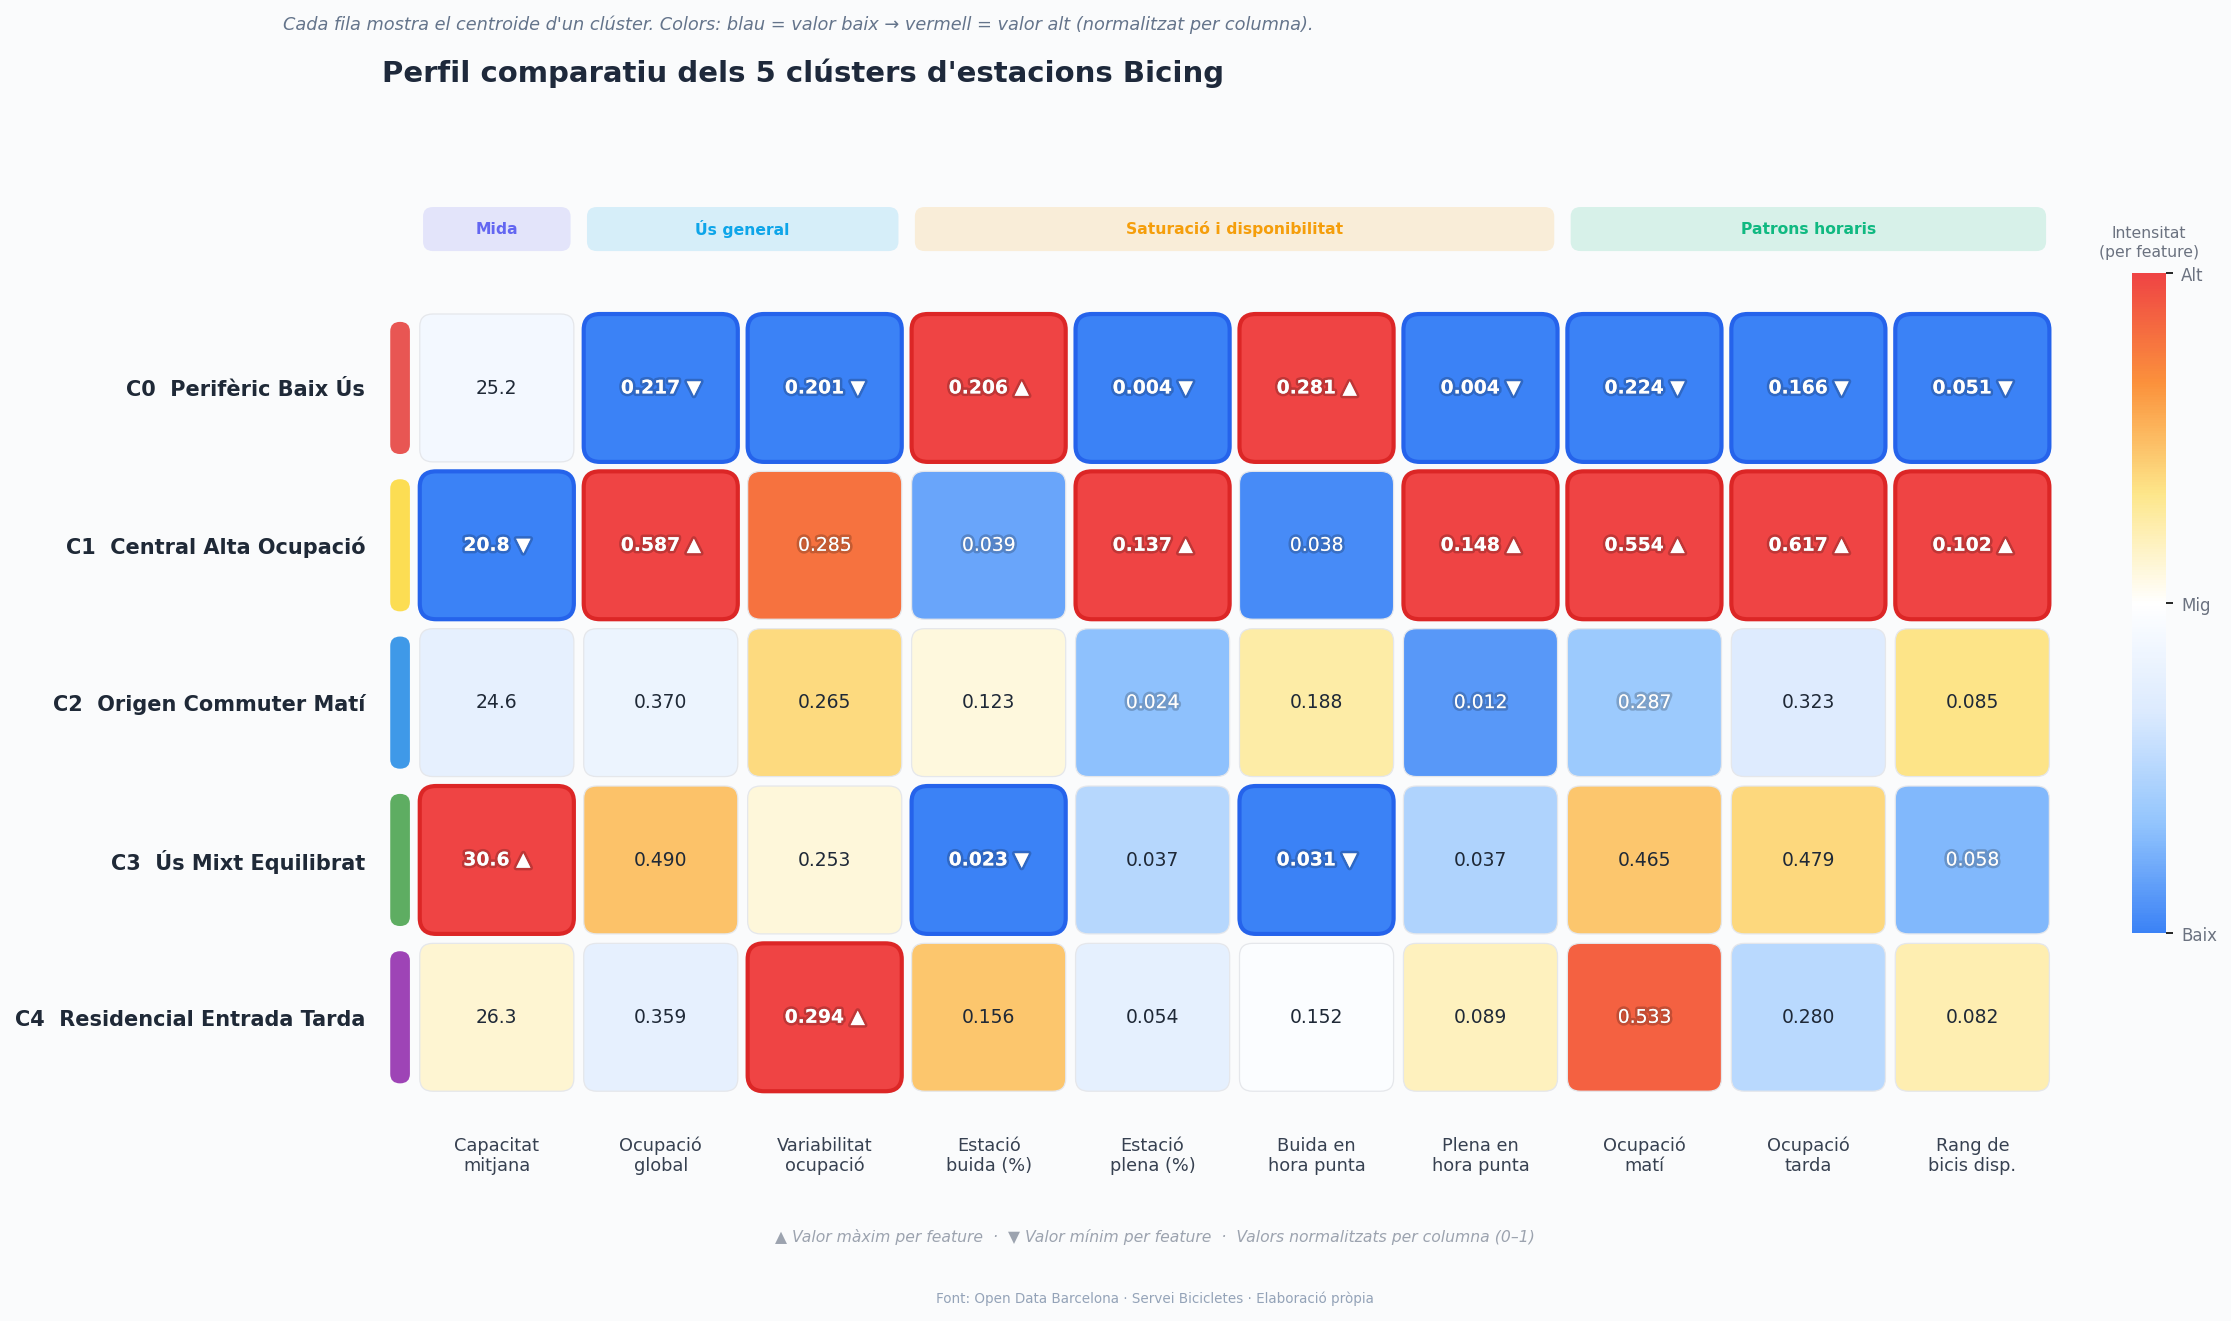

Guardat: png/heatmap_centroids.png


In [14]:
# ── Heatmap de centroides: features clau (disseny visual millorat) ─────────────
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib import patheffects

key_feats = ['capacitat_mitja', 'mitja_nab_global', 'std_nab_global',
             'ratio_buida_global', 'ratio_plena_global',
             'ratio_buida_hora_punta', 'ratio_plena_hora_punta',
             'nab_mitja_punta_matinada', 'nab_mitja_punta_tarda',
             'mitja_rang_bicis_norm']

# ── Etiquetes descriptives per a públic general ──────────────────────────────
feat_labels = [
    'Capacitat\nmitjana',
    'Ocupació\nglobal',
    'Variabilitat\nocupació',
    'Estació\nbuida (%)',
    'Estació\nplena (%)',
    'Buida en\nhora punta',
    'Plena en\nhora punta',
    'Ocupació\nmatí',
    'Ocupació\ntarda',
    'Rang de\nbicis disp.'
]

# ── Agrupació temàtica de features ───────────────────────────────────────────
# Grup 1: Capacitat (0)  |  Grup 2: Ocupació general (1-2)
# Grup 3: Saturació (3-6) |  Grup 4: Patró horari (7-9)
group_boundaries = [1, 3, 7]  # índexs on comença cada nou grup
group_labels = ['Mida', 'Ús general', 'Saturació i disponibilitat', 'Patrons horaris']
group_colors = ['#6366F1', '#0EA5E9', '#F59E0B', '#10B981']

cluster_labels = [f"C{c}  {cluster_names[c]}" for c in range(K_FINAL)]

# ── Matriu de valors originals i normalitzats (min-max per columna) ──────────
n_rows, n_cols = K_FINAL, len(key_feats)
mat_orig = np.zeros((n_rows, n_cols))
mat_norm = np.zeros((n_rows, n_cols))

for j, feat in enumerate(key_feats):
    vals = np.array([centroids_df.loc[c, feat] for c in range(K_FINAL)])
    mat_orig[:, j] = vals
    vmin, vmax = vals.min(), vals.max()
    mat_norm[:, j] = (vals - vmin) / (vmax - vmin) if vmax > vmin else 0.5

# Etiquetes originals amb format intel·ligent
def fmt_val(v):
    if v >= 10:
        return f"{v:.1f}"
    else:
        return f"{v:.3f}"

mat_labels = [[fmt_val(mat_orig[i, j]) for j in range(n_cols)] for i in range(n_rows)]

# ── Paleta de colors: gradient continu (blau fred → blanc → coral càlid) ────
cmap_custom = mcolors.LinearSegmentedColormap.from_list(
    'custom_heatmap',
    ['#3B82F6', '#93C5FD', '#DBEAFE', '#FFFFFF', '#FDE68A', '#FB923C', '#EF4444'],
    N=256
)

# ── Dimensions i layout ─────────────────────────────────────────────────────
cell_w, cell_h = 1.0, 1.0
margin_left = 0.15   # espai per la barra de color del cluster
fig_w = n_cols * cell_w + 5.5
fig_h = n_rows * cell_h + 3.8

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor('#FAFBFC')
ax.set_facecolor('#FAFBFC')

# ── Dibuixem les cel·les amb gradient continu ────────────────────────────────
for j in range(n_cols):
    col_vals = mat_norm[:, j]
    i_min = int(np.argmin(col_vals))
    i_max = int(np.argmax(col_vals))

    for i in range(n_rows):
        v = mat_norm[i, j]
        bg_color = cmap_custom(v)

        # Cel·la amb vores arrodonides
        fancy = FancyBboxPatch(
            (j * cell_w + margin_left + 0.05, i * cell_h + 0.05),
            cell_w - 0.10, cell_h - 0.10,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=bg_color, edgecolor='#E5E7EB', linewidth=0.6,
            zorder=2
        )
        ax.add_patch(fancy)

        # Ressaltar màxim i mínim amb vora especial
        if i == i_max or i == i_min:
            border_color = '#DC2626' if i == i_max else '#2563EB'
            highlight = FancyBboxPatch(
                (j * cell_w + margin_left + 0.03, i * cell_h + 0.03),
                cell_w - 0.06, cell_h - 0.06,
                boxstyle="round,pad=0.0,rounding_size=0.10",
                facecolor='none', edgecolor=border_color,
                linewidth=2.0, linestyle='-', zorder=3
            )
            ax.add_patch(highlight)

        # Text del valor
        txt_color = '#FFFFFF' if v > 0.78 or v < 0.22 else '#1F2937'
        indicator = ''
        if i == i_max:
            indicator = ' ▲'
        elif i == i_min:
            indicator = ' ▼'

        txt = ax.text(
            j * cell_w + margin_left + cell_w / 2,
            i * cell_h + cell_h / 2,
            mat_labels[i][j] + indicator,
            ha='center', va='center',
            fontsize=9, color=txt_color,
            fontweight='bold' if (i == i_max or i == i_min) else 'normal',
            zorder=5
        )
        if v > 0.78 or v < 0.22:
            txt.set_path_effects([
                patheffects.withStroke(linewidth=2.5, foreground='#00000033')
            ])

# ── Barra lateral de color per cluster ───────────────────────────────────────
for i in range(n_rows):
    bar = FancyBboxPatch(
        (0, i * cell_h + 0.08), margin_left - 0.03, cell_h - 0.16,
        boxstyle="round,pad=0.0,rounding_size=0.06",
        facecolor=COLORS_CLUSTER[i], edgecolor='none',
        alpha=0.85, zorder=2
    )
    ax.add_patch(bar)

# ── Barres superiors de grups temàtics ───────────────────────────────────────
group_starts = [0] + group_boundaries
group_ends = group_boundaries + [n_cols]

for g, (gs, ge) in enumerate(zip(group_starts, group_ends)):
    x0 = gs * cell_w + margin_left
    width = (ge - gs) * cell_w
    # Barra de color del grup
    group_bar = FancyBboxPatch(
        (x0 + 0.05, -0.65), width - 0.10, 0.28,
        boxstyle="round,pad=0.0,rounding_size=0.06",
        facecolor=group_colors[g], edgecolor='none',
        alpha=0.15, zorder=2
    )
    ax.add_patch(group_bar)
    ax.text(
        x0 + width / 2, -0.51,
        group_labels[g],
        ha='center', va='center', fontsize=7.5,
        color=group_colors[g], fontweight='bold', zorder=5
    )

# ── Eixos i etiquetes ───────────────────────────────────────────────────────
ax.set_xlim(-0.05, n_cols * cell_w + margin_left + 0.05)
ax.set_ylim(n_rows * cell_h + 0.15, -0.85)

# X-ticks (features)
ax.set_xticks([j * cell_w + margin_left + cell_w / 2 for j in range(n_cols)])
ax.set_xticklabels(feat_labels, fontsize=8.5, color='#374151',
                   ha='center', va='top', linespacing=1.15)

# Y-ticks (clusters)
ax.set_yticks([i * cell_h + cell_h / 2 for i in range(n_rows)])
ax.set_yticklabels(cluster_labels, fontsize=10, color='#1F2937',
                   fontweight='bold')

ax.tick_params(length=0, pad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Barra de color (gradient) ────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.50])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Baix', 'Mig', 'Alt'], fontsize=8, color='#6B7280')
cbar.outline.set_visible(False)
cbar_ax.set_title('Intensitat\n(per feature)', fontsize=7.5, color='#6B7280',
                  pad=8, linespacing=1.3)

# ── Llegenda d'indicadors ────────────────────────────────────────────────────
legend_text = (
    "▲ Valor màxim per feature  ·  ▼ Valor mínim per feature  ·  "
    "Valors normalitzats per columna (0–1)"
)
fig.text(0.50, 0.02, legend_text,
         ha='center', va='center', fontsize=7.5, color='#9CA3AF',
         style='italic')

# ── Títol i subtítol ─────────────────────────────────────────────────────────
ax.set_title(
    'Perfil comparatiu dels 5 clústers d\'estacions Bicing',
    fontsize=14, fontweight='bold', pad=45, color='#1E293B',
    loc='left'
)
fig.text(0.125, 0.935,
    'Cada fila mostra el centroide d\'un clúster. Colors: blau = valor baix → vermell = valor alt (normalitzat per columna).',
    fontsize=8.5, color='#64748B', style='italic')

fig.text(.5, -0.03, 'Font: Open Data Barcelona · Servei Bicicletes · Elaboració pròpia',
         ha='center', fontsize=6.5, color='#94A3B8')

plt.tight_layout(rect=[0, 0.05, 0.90, 0.93])
plt.savefig('png/heatmap_centroids.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Guardat: png/heatmap_centroids.png')


---
## 10. Distribució de districtes per cluster

Visualitzem com es reparteixen les estacions de cada cluster entre els districtes de Barcelona, en valors absoluts i percentuals.

In [15]:
# ── Taula creuada cluster × districte ─────────────────────────────────────────
crosstab = pd.crosstab(df_valid['cluster_name'], df_valid['nom_districte'])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

print("Estacions per cluster i districte:")
display(crosstab)

Estacions per cluster i districte:


nom_districte,Ciutat Vella,Eixample,Gràcia,Horta-Guinardó,Les Corts,Nou Barris,Sant Andreu,Sant Martí,Sants-Montjuïc,Sarrià-Sant Gervasi
cluster_name,,,,,,,,,,
Central Alta Ocupació,26,1,0,0,0,0,0,12,3,0
Origen Commuter Matí,5,60,13,11,3,5,21,17,27,0
Perifèric Baix Ús,1,12,11,22,19,23,3,0,6,35
Residencial Entrada Tarda,6,23,0,0,13,0,1,13,2,1
Ús Mixt Equilibrat,22,13,0,0,0,1,22,46,18,0


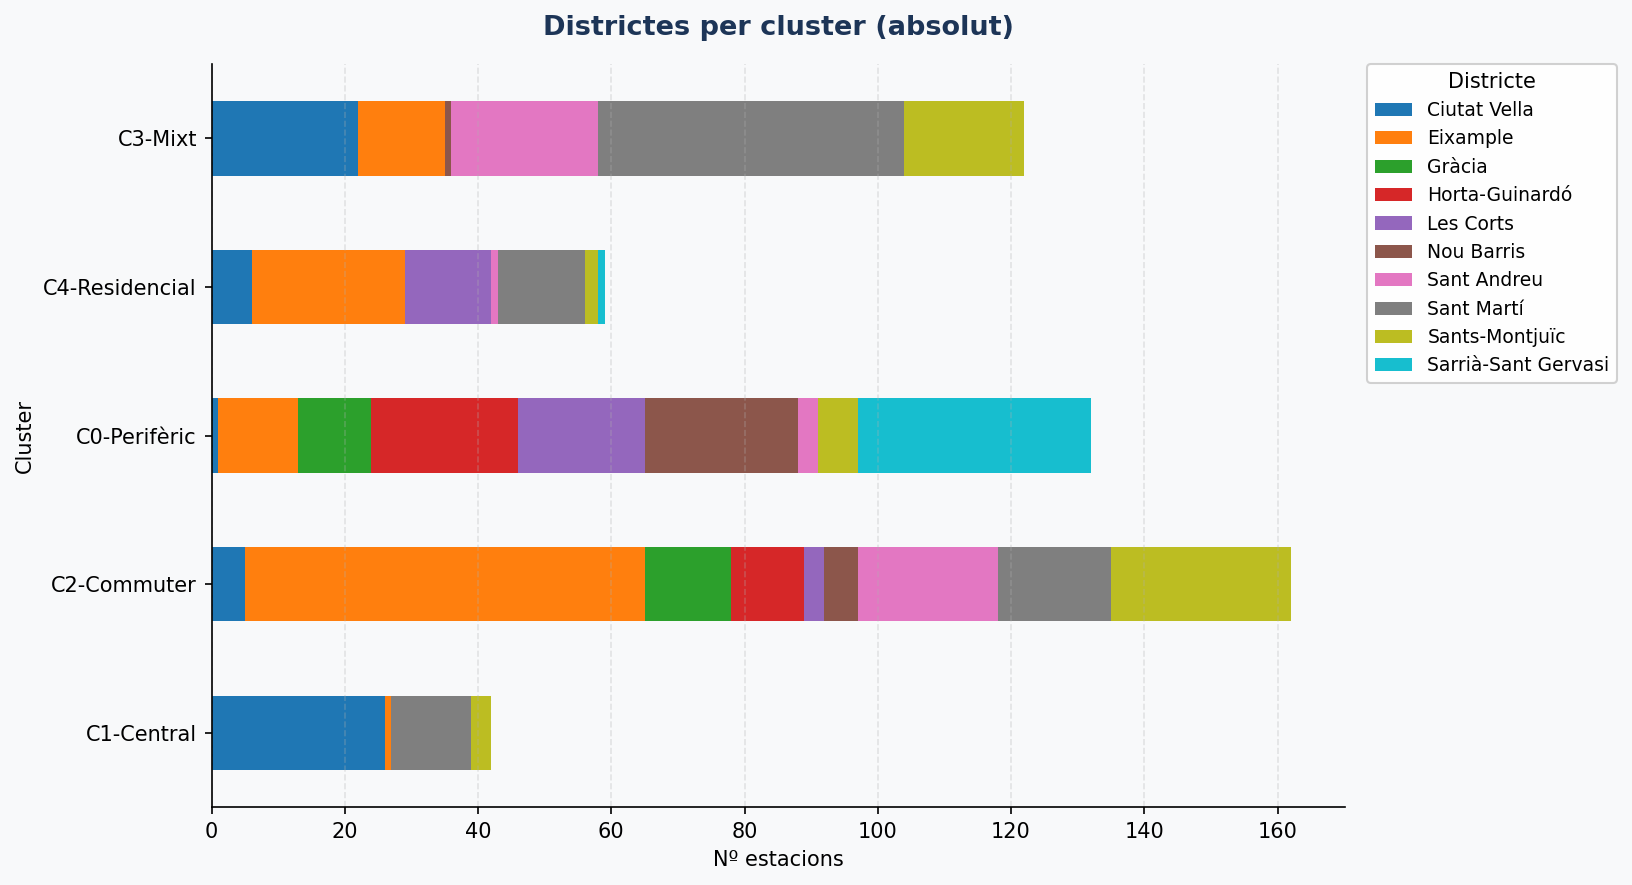

Guardat: png/district_absolut.png


In [16]:
# ── Gràfic de districtes per cluster (absolut) ────────────────────────────────
short_labels = {
    "Perifèric Baix Ús": "C0-Perifèric",
    "Central Alta Ocupació": "C1-Central",
    "Origen Commuter Matí": "C2-Commuter",
    "Ús Mixt Equilibrat": "C3-Mixt",
    "Residencial Entrada Tarda": "C4-Residencial",
}

crosstab_short = crosstab.copy()
crosstab_short.index = [short_labels.get(i, i) for i in crosstab.index]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#F8F9FA')
crosstab_short.plot(kind='barh', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Districtes per cluster (absolut)',
             fontsize=13, fontweight='bold', pad=14, color='#1D3557')
ax.set_ylabel('Cluster', fontsize=10)
ax.set_xlabel('Nº estacions', fontsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(title='Districte', bbox_to_anchor=(1.02, 1), loc='upper left',
          borderaxespad=0, fontsize=9, framealpha=.9)
ax.grid(axis='x', ls='--', alpha=.3)

plt.tight_layout()
plt.savefig('png/district_absolut.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardat: png/district_absolut.png')

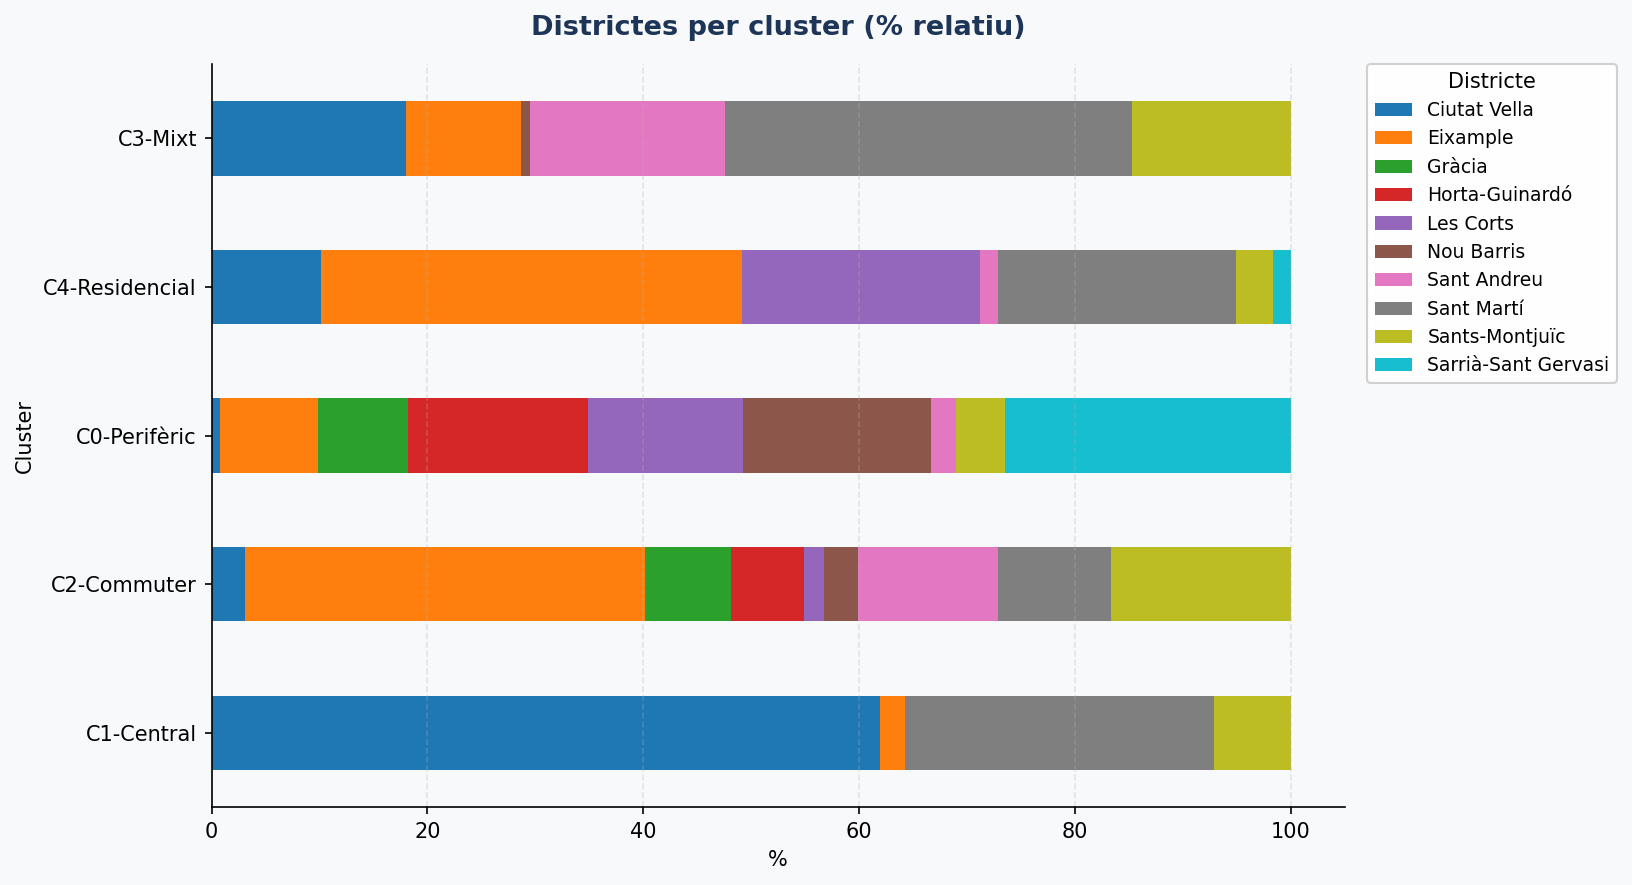

Guardat: png/district_relatiu.png


In [17]:
# ── Gràfic de districtes per cluster (% relatiu) ──────────────────────────────
crosstab_pct_short = crosstab_pct.copy()
crosstab_pct_short.index = [short_labels.get(i, i) for i in crosstab_pct.index]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#F8F9FA')
crosstab_pct_short.plot(kind='barh', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Districtes per cluster (% relatiu)',
             fontsize=13, fontweight='bold', pad=14, color='#1D3557')
ax.set_ylabel('Cluster', fontsize=10)
ax.set_xlabel('%', fontsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(title='Districte', bbox_to_anchor=(1.02, 1), loc='upper left',
          borderaxespad=0, fontsize=9, framealpha=.9)
ax.grid(axis='x', ls='--', alpha=.3)

plt.tight_layout()
plt.savefig('png/district_relatiu.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardat: png/district_relatiu.png')

---
## 11. Mapa interactiu del clustering

Mapa amb totes les estacions classificades per cluster. Cada cercle representa una estació i el **color** indica el cluster assignat. Es pot obrir el fitxer HTML resultant en un navegador per explorar-lo interactivament.

> **Diapositiva 8** de la presentació.

In [18]:
# ── Mapa interactiu amb Folium ────────────────────────────────────────────────
center_lat = df_valid['lat'].mean()
center_lon = df_valid['lon'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
               tiles='CartoDB positron',
               attr='© OpenStreetMap contributors, © CartoDB')

# Afegim un cercle per cada estació
for c in range(K_FINAL):
    mask = df_valid['cluster'] == c
    sub = df_valid[mask]
    color = COLORS_CLUSTER[c]
    for _, row in sub.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            tooltip=(
                f"Estació {int(row['id_estacio'])} | {row['nom_districte']}<br>"
                f"Cluster: C{c} - {cluster_names[c]}<br>"
                f"NAB global: {row['mitja_nab_global']:.3f}<br>"
                f"Ratio buid.: {row['ratio_buida_global']:.3f}<br>"
                f"Ratio plena: {row['ratio_plena_global']:.3f}"
            )
        ).add_to(m)

# Títol
m.get_root().html.add_child(folium.Element(f"""
<div style="position:fixed;top:16px;left:50%;transform:translateX(-50%);
    z-index:1000;background:white;padding:9px 22px;border-radius:9px;
    box-shadow:0 2px 8px rgba(0,0,0,.22);font-family:Arial,sans-serif;
    font-size:15px;font-weight:bold;color:#1D3557;pointer-events:none;">
  Bicing Barcelona — Clusters d'estacions (2022–2024)
</div>
"""))

# Llegenda
legend_items = ""
for c in range(K_FINAL):
    n = (df_valid['cluster'] == c).sum()
    legend_items += (
        f'<div style="display:flex;align-items:center;margin-bottom:5px;">'
        f'<div style="width:14px;height:14px;border-radius:50%;'
        f'background:{COLORS_CLUSTER[c]};margin-right:8px;flex-shrink:0;"></div>'
        f'<span style="font-size:12px;">C{c}: {cluster_names[c]} ({n})</span></div>'
    )

legend_html = f"""
<div style="position:fixed; bottom:30px; left:30px; background:white;
     border:1px solid #ccc; border-radius:6px; padding:12px 16px;
     font-family:Arial,sans-serif; box-shadow:2px 2px 6px rgba(0,0,0,0.2);
     z-index:9999;">
    <div style="font-weight:bold;margin-bottom:8px;font-size:13px;">Clusters Bicing</div>
    {legend_items}
</div>
"""
m.get_root().html.add_child(Element(legend_html))

m.save('html/mapa_clusters_interactiu.html')
print('HTML guardat: html/mapa_clusters_interactiu.html')
display(m)

HTML guardat: html/mapa_clusters_interactiu.html


---
## 12. Exportació dels resultats

Guardem els resultats en fitxers CSV i a la base de dades DuckDB.

In [19]:
# ── Fitxer principal: cada estació amb el seu cluster ─────────────────────────
output_cols = ['id_estacio', 'lat', 'lon', 'nom_districte',
               'cluster', 'cluster_name'] + feature_cols
df_valid[output_cols].to_csv('csv/estacio_cluster.csv', index=False)
print(f"Guardat: csv/estacio_cluster.csv ({len(df_valid)} files)")

# ── Guardar a DuckDB ─────────────────────────────────────────────────────────
con.register("estacio_df", df_valid)
con.execute("CREATE OR REPLACE TABLE estacio_cluster AS SELECT * FROM estacio_df")
print("Guardat taula estacio_cluster a", DB_PATH)

# ── Centroides ───────────────────────────────────────────────────────────────
centroids_df.to_csv('csv/cluster_centroids.csv', index=False)
print("Guardat: csv/cluster_centroids.csv")

Guardat: csv/estacio_cluster.csv (517 files)
Guardat taula estacio_cluster a bicicletes.duckdb
Guardat: csv/cluster_centroids.csv


In [20]:
# ── Taula resum per cluster ───────────────────────────────────────────────────
summary_rows = []
for c in range(K_FINAL):
    mask = df_valid['cluster'] == c
    sub = df_valid[mask]
    summary_rows.append({
        'cluster': c,
        'cluster_name': cluster_names[c],
        'n_stations': mask.sum(),
        'top_district': sub['nom_districte'].value_counts().index[0],
        'capacitat_mitja_mean': sub['capacitat_mitja'].mean(),
        'nab_global_mean': sub['mitja_nab_global'].mean(),
        'std_nab_mean': sub['std_nab_global'].mean(),
        'ratio_buida_mean': sub['ratio_buida_global'].mean(),
        'ratio_plena_mean': sub['ratio_plena_global'].mean(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('csv/cluster_summary.csv', index=False)
print("Guardat: csv/cluster_summary.csv")
print()
print("Resum final:")
display(summary_df[['cluster', 'cluster_name', 'n_stations', 'top_district',
                     'nab_global_mean', 'ratio_buida_mean', 'ratio_plena_mean']].round(3))

Guardat: csv/cluster_summary.csv

Resum final:


,cluster,cluster_name,n_stations,top_district,nab_global_mean,ratio_buida_mean,ratio_plena_mean
0,0,Perifèric Baix Ús,132,Sarrià-Sant Gervasi,0.217,0.206,0.004
1,1,Central Alta Ocupació,42,Ciutat Vella,0.587,0.039,0.137
2,2,Origen Commuter Matí,162,Eixample,0.370,0.123,0.024
3,3,Ús Mixt Equilibrat,122,Sant Martí,0.490,0.023,0.037
4,4,Residencial Entrada Tarda,59,Eixample,0.359,0.156,0.054


---
## 13. Tancament

Tanquem la connexió i llistem tots els fitxers generats.

In [21]:
con.close()
print('Connexió a DuckDB tancada.\n')

print('=== Fitxers generats ===')
for carpeta in ['html', 'png', 'csv']:
    fitxers = sorted(glob.glob(f'{carpeta}/*'))
    if fitxers:
        print(f'\n{carpeta.upper()}/  ({len(fitxers)} fitxers)')
        for f in fitxers:
            print(f'  {f}  ({os.path.getsize(f)/1024:.0f} KB)')

Connexió a DuckDB tancada.

=== Fitxers generats ===

HTML/  (3 fitxers)
  html\bicicletes_mapa_estacions.html  (451 KB)
  html\mapa_clusters_interactiu.html  (419 KB)
  html\mapa_problema_combinat.html  (731 KB)

PNG/  (14 fitxers)
  png\02_evolucio_mensual.png  (159 KB)
  png\03_patrons_horaris.png  (50 KB)
  png\04_patrons_horaris_per_any.png  (227 KB)
  png\06_heatmap_dia_hora.png  (42 KB)
  png\07_districtes.png  (53 KB)
  png\11_distribucio_estacions.png  (70 KB)
  png\bicicletes_heatmap_hora_dia.png  (41 KB)
  png\bicicletes_mensual.png  (165 KB)
  png\bicicletes_viatges_mensuals.png  (176 KB)
  png\district_absolut.png  (70 KB)
  png\district_relatiu.png  (65 KB)
  png\elbow_silhouette.png  (88 KB)
  png\heatmap_centroids.png  (315 KB)
  png\nab_profiles.png  (163 KB)

CSV/  (13 fitxers)
  csv\01_evolucio_anual.csv  (0 KB)
  csv\02_evolucio_mensual.csv  (1 KB)
  csv\03_patrons_horaris.csv  (0 KB)
  csv\04_patrons_horaris_per_any.csv  (2 KB)
  csv\06_heatmap_dia_hora.csv  (3 KB)